# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[ResNet-18] Epoch   1/100 | LR: 2.93e-04 | train loss 0.9832 acc 0.628 | val loss 0.8858 acc 0.741 *


[ResNet-18] Epoch   2/100 | LR: 2.93e-04 | train loss 0.8013 acc 0.688 | val loss 0.7159 acc 0.671 *


[ResNet-18] Epoch   3/100 | LR: 2.93e-04 | train loss 0.7645 acc 0.697 | val loss 0.6390 acc 0.718 *


[ResNet-18] Epoch   4/100 | LR: 2.93e-04 | train loss 0.6813 acc 0.742 | val loss 0.4453 acc 0.788 *


...

[ResNet-18] Epoch  10/100 | LR: 2.93e-04 | train loss 0.5293 acc 0.800 | val loss 0.5331 acc 0.729


[ResNet-18] Epoch  11/100 | LR: 2.93e-04 | train loss 0.5430 acc 0.797 | val loss 0.4849 acc 0.800


[ResNet-18] Epoch  12/100 | LR: 2.93e-04 | train loss 0.4628 acc 0.839 | val loss 0.5384 acc 0.759


[ResNet-18] Epoch  13/100 | LR: 2.93e-04 | train loss 0.4414 acc 0.852 | val loss 0.6010 acc 0.765


[ResNet-18] Epoch  14/100 | LR: 2.93e-04 | train loss 0.4273 acc 0.846 | val loss 0.5776 acc 0.741

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 14.

[ResNet-18] Restored best checkpoint (val loss = 0.4453)


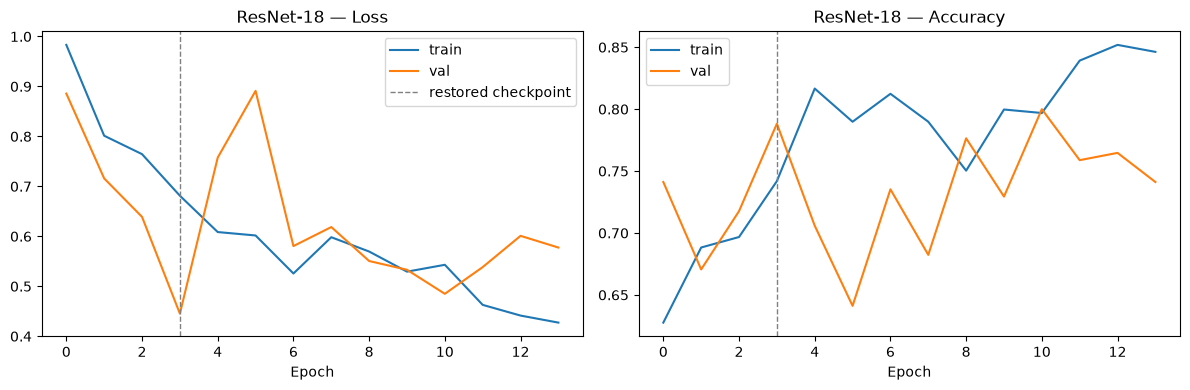

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.675


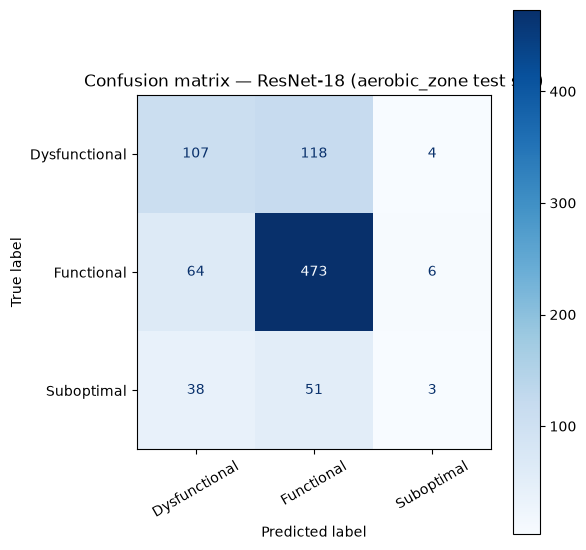

               precision    recall  f1-score   support

Dysfunctional      0.512     0.467     0.489       229
   Functional      0.737     0.871     0.798       543
   Suboptimal      0.231     0.033     0.057        92

     accuracy                          0.675       864
    macro avg      0.493     0.457     0.448       864
 weighted avg      0.623     0.675     0.637       864



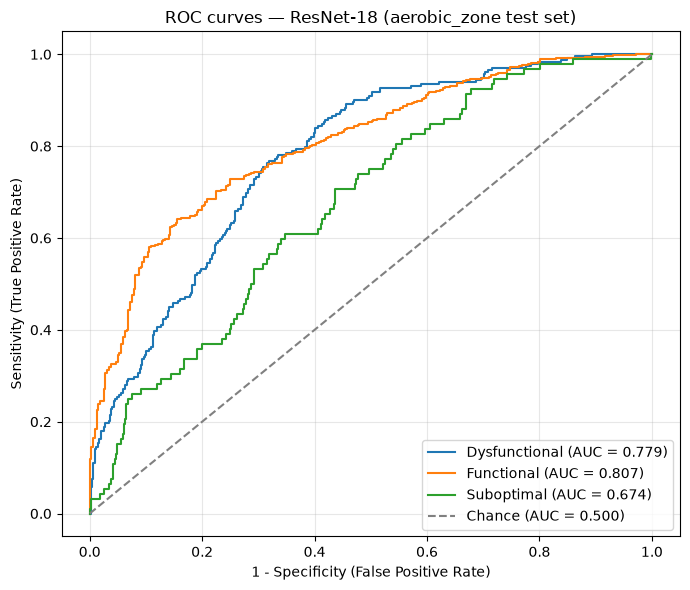

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.779
  Functional     : 0.807
  Suboptimal     : 0.674

Mean AUC (over 3/3 classes with test examples): 0.753


(np.float64(0.6747685185185185),
 {'Dysfunctional': 0.7792868686174055,
  'Functional': 0.8066355713900507,
  'Suboptimal': 0.6743917548997522})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_resnet18_Waterval.pkl


Saved model weights to ../models/aerobic_zone_resnet18_cnn.pt
